# 02 — Risk Profile (2003-09-20 to 2024-12-31)


Data source: `data/processed/master_daily_2003_2024.csv` (built by `scripts/build_master_dataset.py`)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 140)

In [2]:
df = pd.read_csv(
    "../data/processed/master_daily_2003_2024.csv",
    parse_dates=["date"],
    index_col="date",
).sort_index()

df.shape, df.index.min(), df.index.max()

((5356, 57),
 Timestamp('2003-09-22 00:00:00'),
 Timestamp('2024-12-31 00:00:00'))

In [3]:
df.columns[:25]

Index(['SPY_RET', 'AGG_RET', 'mktrf', 'smb', 'hml', 'rf', 'umd', 'Agric', 'Food', 'Soda', 'Beer', 'Smoke', 'Toys', 'Fun', 'Books', 'Hshld',
       'Clths', 'Hlth', 'MedEq', 'Drugs', 'Chems', 'Rubbr', 'Txtls', 'BldMt', 'Cnstr'],
      dtype='object')

In [4]:
assert "SPY_RET" in df.columns and "AGG_RET" in df.columns

df["P_60_40"] = 0.6 * df["SPY_RET"] + 0.4 * df["AGG_RET"]

df["P_SPY"] = df["SPY_RET"]
df["P_AGG"] = df["AGG_RET"]

df[["P_SPY", "P_AGG", "P_60_40"]].head()

/var/folders/y1/t79wmh0x3zvfvmjwgtpyh9h40000gn/T/ipykernel_2140/2418834140.py:3: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df["P_60_40"] = 0.6 * df["SPY_RET"] + 0.4 * df["AGG_RET"]
/var/folders/y1/t79wmh0x3zvfvmjwgtpyh9h40000gn/T/ipykern

,P_SPY,P_AGG,P_60_40
date,,,
2003-09-22,-0.010803,NaN,NaN
2003-09-23,0.003803,NaN,NaN
2003-09-24,-0.017777,NaN,NaN
2003-09-25,-0.008209,NaN,NaN
2003-09-26,-0.003291,NaN,NaN


In [5]:
TRADING_DAYS = 252

def ann_vol(x: pd.Series) -> float:
    return float(x.std(ddof=0) * np.sqrt(TRADING_DAYS))

def ann_mean(x: pd.Series) -> float:
    return float(x.mean() * TRADING_DAYS)

def sharpe(x: pd.Series) -> float:
    vol = ann_vol(x)
    return float(ann_mean(x) / vol) if vol > 0 else np.nan

def wealth_index(returns: pd.Series, start: float = 1.0) -> pd.Series:
    return start * (1.0 + returns.fillna(0.0)).cumprod()

def max_drawdown(returns: pd.Series) -> float:
    w = wealth_index(returns)
    peak = w.cummax()
    dd = (w / peak) - 1.0
    return float(dd.min())

def drawdown_series(returns: pd.Series) -> pd.Series:
    w = wealth_index(returns)
    peak = w.cummax()
    return (w / peak) - 1.0

In [6]:
assets = ["P_SPY", "P_AGG", "P_60_40"]

summary = pd.DataFrame({
    "Ann Mean": [ann_mean(df[c]) for c in assets],
    "Ann Vol":  [ann_vol(df[c]) for c in assets],
    "Sharpe (rf≈0)": [sharpe(df[c]) for c in assets],
    "Max Drawdown": [max_drawdown(df[c]) for c in assets],
}).set_index(pd.Index(assets, name="Series"))

summary

,Ann Mean,Ann Vol,Sharpe (rf≈0),Max Drawdown
Series,,,,
P_SPY,0.117791,0.186477,0.631662,-0.552011
P_AGG,0.029933,0.052259,0.572777,-0.184371
P_60_40,0.083739,0.113546,0.737487,-0.347142


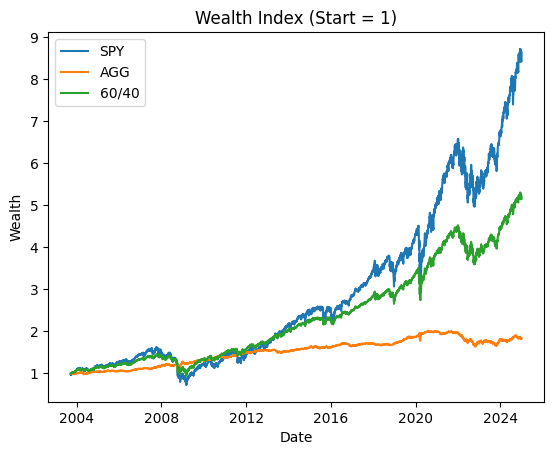

In [7]:
w = pd.DataFrame({
    "SPY": wealth_index(df["P_SPY"]),
    "AGG": wealth_index(df["P_AGG"]),
    "60/40": wealth_index(df["P_60_40"]),
})

plt.figure()
plt.plot(w.index, w["SPY"], label="SPY")
plt.plot(w.index, w["AGG"], label="AGG")
plt.plot(w.index, w["60/40"], label="60/40")
plt.title("Wealth Index (Start = 1)")
plt.xlabel("Date")
plt.ylabel("Wealth")
plt.legend()
plt.show()

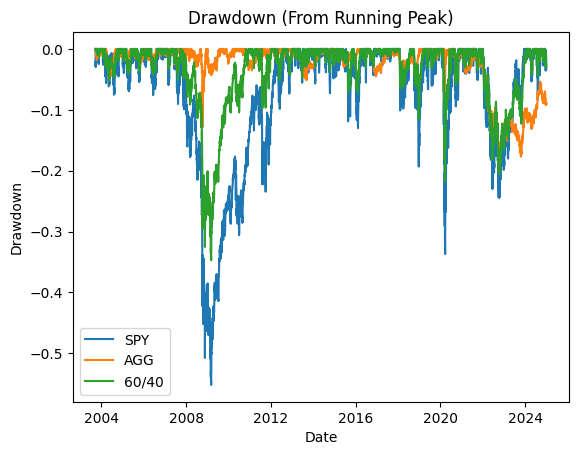

In [8]:
dd = pd.DataFrame({
    "SPY": drawdown_series(df["P_SPY"]),
    "AGG": drawdown_series(df["P_AGG"]),
    "60/40": drawdown_series(df["P_60_40"]),
})

plt.figure()
plt.plot(dd.index, dd["SPY"], label="SPY")
plt.plot(dd.index, dd["AGG"], label="AGG")
plt.plot(dd.index, dd["60/40"], label="60/40")
plt.title("Drawdown (From Running Peak)")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.legend()
plt.show()

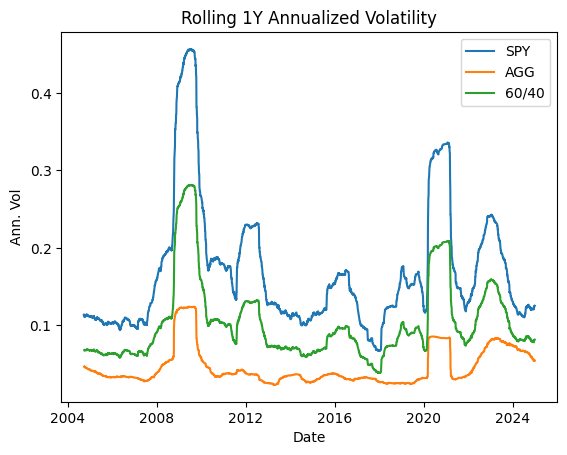

In [9]:
roll_window = 252

roll_vol = df[["P_SPY", "P_AGG", "P_60_40"]].rolling(roll_window).std(ddof=0) * np.sqrt(TRADING_DAYS)

plt.figure()
plt.plot(roll_vol.index, roll_vol["P_SPY"], label="SPY")
plt.plot(roll_vol.index, roll_vol["P_AGG"], label="AGG")
plt.plot(roll_vol.index, roll_vol["P_60_40"], label="60/40")
plt.title("Rolling 1Y Annualized Volatility")
plt.xlabel("Date")
plt.ylabel("Ann. Vol")
plt.legend()
plt.show()

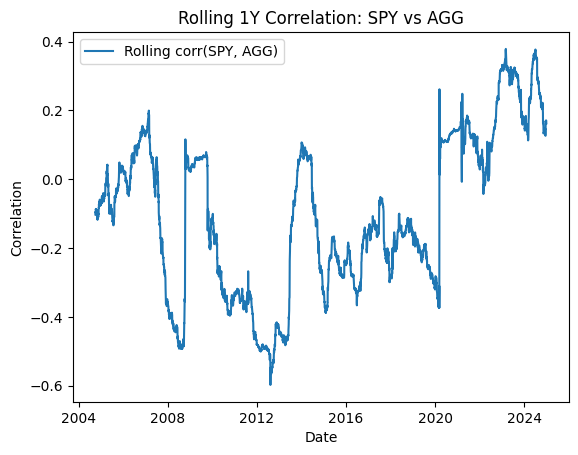

In [10]:
roll_corr = df["SPY_RET"].rolling(roll_window).corr(df["AGG_RET"])

plt.figure()
plt.plot(roll_corr.index, roll_corr, label="Rolling corr(SPY, AGG)")
plt.title("Rolling 1Y Correlation: SPY vs AGG")
plt.xlabel("Date")
plt.ylabel("Correlation")
plt.legend()
plt.show()

In [11]:
windows = {
    "GFC (2008-09 to 2009-03)": ("2008-09-01", "2009-03-31"),
    "COVID (2020-02 to 2020-04)": ("2020-02-01", "2020-04-30"),
    "Rates shock (2022-01 to 2022-10)": ("2022-01-01", "2022-10-31"),
}

rows = []
for name, (a, b) in windows.items():
    sub = df.loc[a:b, ["P_SPY", "P_AGG", "P_60_40"]]
    rows.append({
        "Window": name,
        "SPY cum return": float((1 + sub["P_SPY"]).prod() - 1),
        "AGG cum return": float((1 + sub["P_AGG"]).prod() - 1),
        "60/40 cum return": float((1 + sub["P_60_40"]).prod() - 1),
        "SPY max DD": max_drawdown(sub["P_SPY"]),
        "AGG max DD": max_drawdown(sub["P_AGG"]),
        "60/40 max DD": max_drawdown(sub["P_60_40"]),
    })

stress = pd.DataFrame(rows).set_index("Window")
stress

,SPY cum return,AGG cum return,60/40 cum return,SPY max DD,AGG max DD,60/40 max DD
Window,,,,,,
GFC (2008-09 to 2009-03),-0.369479,0.034315,-0.213889,-0.460522,-0.128331,-0.290357
COVID (2020-02 to 2020-04),-0.091585,0.027874,-0.035715,-0.336998,-0.095792,-0.217049
Rates shock (2022-01 to 2022-10),-0.177454,-0.154771,-0.163845,-0.244975,-0.160342,-0.203161


## Risk Profile Analysis (Long-Run Characteristics)

### Summary Statistics

| Portfolio | Annual Mean | Annual Volatility | Sharpe (rf ≈ 0) | Max Drawdown |
|----------|------------|-------------------|------------------|--------------|
| SPY | 11.78% | 18.65% | 0.63 | −55.20% |
| AGG | 2.99% | 5.23% | 0.57 | −18.44% |
| 60/40 | 8.37% | 11.35% | **0.74** | −34.71% |

### Interpretation

- **SPY** delivers the highest long-run return but is exposed to severe tail risk, with a maximum drawdown exceeding 55%.
- **AGG** provides stability and downside protection but offers limited growth.
- The **60/40 portfolio** balances these characteristics:
  - Volatility is substantially lower than SPY,
  - Drawdowns are materially reduced,
  - Risk-adjusted performance (Sharpe ratio) is the highest among the three.

**Key takeaway:**  
Diversification improves risk-adjusted returns at the cost of some upside potential.

## Wealth Index (Cumulative Performance)

The wealth index plot illustrates the long-term compounding paths of SPY, AGG, and the 60/40 portfolio.

### Observations

- SPY dominates cumulative wealth, particularly after 2010 during prolonged equity market expansion.
- AGG grows steadily but slowly, reflecting its defensive nature.
- The 60/40 portfolio tracks SPY during expansions but with a noticeably smoother trajectory.

### Interpretation

While SPY maximizes terminal wealth, the smoother growth of the 60/40 portfolio highlights the benefit of volatility reduction rather than return maximization alone.  
This visual captures the classic trade-off between growth and stability.

## Drawdown Analysis

The drawdown plot highlights the portfolios’ exposure to tail risk across major stress events.

### Key Episodes

- **Global Financial Crisis (2008–2009):**
  - SPY experienced drawdowns exceeding −50%.
  - The 60/40 portfolio limited losses to roughly −30%.
  - AGG provided strong downside protection with drawdowns around −13%.

- **COVID-19 Crash (2020):**
  - Equity drawdowns were sharp but short-lived.
  - The 60/40 portfolio again cushioned losses relative to SPY.

- **Rate Shock (2022):**
  - All three portfolios experienced drawdowns simultaneously.
  - Bonds failed to hedge equities effectively.

### Interpretation

Diversification performs well in equity-driven crises but becomes fragile when both equities and bonds sell off together, as observed in 2022.

## Stress Window Performance

| Window | SPY Cum Return | AGG Cum Return | 60/40 Cum Return | SPY Max DD | AGG Max DD | 60/40 Max DD |
|------|---------------|---------------|-----------------|-----------|------------|--------------|
| GFC (2008–09) | −36.95% | +3.43% | −21.39% | −46.05% | −12.83% | −29.04% |
| COVID (2020) | −9.16% | +2.79% | −3.57% | −33.70% | −9.58% | −21.70% |
| Rate Shock (2022) | −17.75% | −15.48% | −16.38% | −24.50% | −16.03% | −20.32% |

### Interpretation

- During equity crashes (GFC, COVID), bonds act as an effective hedge.
- During inflation-driven rate shocks (2022), bond protection disappears.
- As a result, the 60/40 portfolio loses its traditional defensive advantage.

## Rolling Volatility and Correlation

The rolling volatility and correlation plots reveal the time-varying nature of diversification.

### Observations

- Equity volatility spikes sharply during crisis periods (2008–09, 2020).
- Bond volatility remains low for most of the sample but rises in 2022.
- The rolling correlation between SPY and AGG:
  - Is often negative during equity crises,
  - Turns positive during rate-driven stress regimes.

### Key Insight

The effectiveness of diversification depends on the macroeconomic regime.  
In particular, rising interest-rate environments undermine the traditional stock–bond diversification channel.

## Summary

- The 60/40 portfolio delivers superior risk-adjusted performance over the long run.
- Diversification significantly reduces drawdowns in equity-led crises.
- However, diversification is **regime-dependent** and can fail during inflationary or rate-driven shocks.
- These findings motivate a deeper investigation into **regime-specific risk decomposition**, which is explored in the next notebook.